# Sudoku Dataset Visualization

Detailed visualization of `data/sudoku-extreme-1k-aug-1000`.

## Data Format
- **Value encoding**: 1 = blank cell, 2-10 = digits 1-9 (+1 offset), 0 = PAD
- **inputs**: puzzle (some cells are blank=1)
- **labels**: solution (all cells are 2-10)
- **train**: 1000 puzzles x 1001 variations (1 original + 1000 augmentations)
- **test**: separate puzzle set without augmentation

In [1]:
import os, json, sys
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.colors as mcolors
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.family'] = 'DejaVu Sans'

DATA_DIR = 'data/sudoku-extreme-1k-aug-1000'

print('Numpy version:', np.__version__)

Numpy version: 2.4.2


## 1. Data Loading (puzzle_dataset.py style)

In [2]:
from data.common import PuzzleDatasetMetadata

def load_split(split):
    """Load data the same way as _lazy_load_dataset in puzzle_dataset.py"""
    split_dir = os.path.join(DATA_DIR, split)

    with open(os.path.join(split_dir, 'dataset.json')) as f:
        metadata = PuzzleDatasetMetadata(**json.load(f))

    field_mmap_modes = {
        'inputs':             'r',    # mmap for large arrays
        'labels':             'r',    # mmap
        'puzzle_identifiers': None,   # keep in memory
        'puzzle_indices':     None,
        'group_indices':      None,
    }

    data = {}
    for set_name in metadata.sets:
        data[set_name] = {
            field: np.load(
                os.path.join(split_dir, f'{set_name}__{field}.npy'),
                mmap_mode=mmap_mode
            )
            for field, mmap_mode in field_mmap_modes.items()
        }

    return metadata, data

train_meta, train_data = load_split('train')
test_meta,  test_data  = load_split('test')
ds_train = train_data['all']
ds_test  = test_data['all']

print('=== train metadata ===')
print(train_meta.model_dump())
print('\n=== test metadata ===')
print(test_meta.model_dump())

=== train metadata ===
{'pad_id': 0, 'ignore_label_id': 0, 'blank_identifier_id': 0, 'vocab_size': 11, 'seq_len': 81, 'num_puzzle_identifiers': 1, 'total_groups': 1000, 'mean_puzzle_examples': 1.0, 'sets': ['all']}

=== test metadata ===
{'pad_id': 0, 'ignore_label_id': 0, 'blank_identifier_id': 0, 'vocab_size': 11, 'seq_len': 81, 'num_puzzle_identifiers': 1, 'total_groups': 422786, 'mean_puzzle_examples': 1.0, 'sets': ['all']}


## 2. Dataset Overview

In [3]:
print('='*55)
print('  Train split')
print('='*55)
for name, arr in ds_train.items():
    print(f'  {name:25s}  shape={str(arr.shape):20s}  dtype={arr.dtype}')

print()
print('='*55)
print('  Test split')
print('='*55)
for name, arr in ds_test.items():
    print(f'  {name:25s}  shape={str(arr.shape):20s}  dtype={arr.dtype}')

print()
n_train_groups   = train_meta.total_groups
n_train_examples = ds_train['inputs'].shape[0]
n_test_examples  = ds_test['inputs'].shape[0]
aug_per_puzzle   = n_train_examples // n_train_groups - 1  # 1 original + N augmentations

print(f'Train: {n_train_groups} original puzzles x {aug_per_puzzle+1} variations = {n_train_examples:,} samples')
print(f'Test : {n_test_examples:,} samples (no augmentation)')
print(f'Vocab size: {train_meta.vocab_size}  (0=PAD, 1=blank, 2-10=digits 1-9)')
print(f'Seq length: {train_meta.seq_len}  (9x9=81)')

  Train split
  inputs                     shape=(1001000, 81)         dtype=int64
  labels                     shape=(1001000, 81)         dtype=int64
  puzzle_identifiers         shape=(1001000,)            dtype=int32
  puzzle_indices             shape=(1001001,)            dtype=int32
  group_indices              shape=(1001,)               dtype=int32

  Test split
  inputs                     shape=(422786, 81)          dtype=uint8
  labels                     shape=(422786, 81)          dtype=uint8
  puzzle_identifiers         shape=(422786,)             dtype=int32
  puzzle_indices             shape=(422787,)             dtype=int32
  group_indices              shape=(422787,)             dtype=int32

Train: 1000 original puzzles x 1001 variations = 1,001,000 samples
Test : 422,786 samples (no augmentation)
Vocab size: 11  (0=PAD, 1=blank, 2-10=digits 1-9)
Seq length: 81  (9x9=81)


## 3. Index Structure Visualization

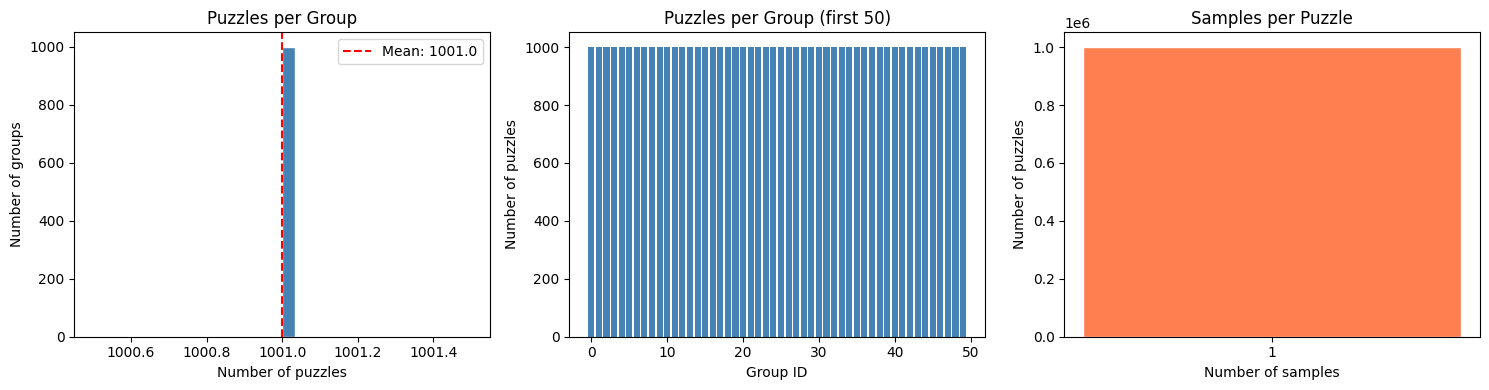

group_indices:  total groups = 1000,  puzzles/group = 1001-1001
puzzle_indices: total puzzles = 1001000,  samples/puzzle = 1-1


In [4]:
gi = ds_train['group_indices']   # (1001,)
pi = ds_train['puzzle_indices']  # (1001001,)

examples_per_group  = gi[1:] - gi[:-1]   # number of puzzles per group
examples_per_puzzle = pi[1:] - pi[:-1]   # number of examples per puzzle (all 1)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Distribution of puzzles per group
axes[0].hist(examples_per_group, bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Puzzles per Group')
axes[0].set_xlabel('Number of puzzles')
axes[0].set_ylabel('Number of groups')
axes[0].axvline(examples_per_group.mean(), color='red', linestyle='--',
                label=f'Mean: {examples_per_group.mean():.1f}')
axes[0].legend()

# Puzzles per group for the first 50 groups
n_show = 50
axes[1].bar(range(n_show), examples_per_group[:n_show], color='steelblue', width=0.8)
axes[1].set_title(f'Puzzles per Group (first {n_show})')
axes[1].set_xlabel('Group ID')
axes[1].set_ylabel('Number of puzzles')

# Samples per puzzle (should all be 1)
unique_epp, counts_epp = np.unique(examples_per_puzzle, return_counts=True)
axes[2].bar(unique_epp.astype(str), counts_epp, color='coral', edgecolor='white')
axes[2].set_title('Samples per Puzzle')
axes[2].set_xlabel('Number of samples')
axes[2].set_ylabel('Number of puzzles')

plt.tight_layout()
plt.show()

print(f'group_indices:  total groups = {len(gi)-1},  puzzles/group = {examples_per_group.min()}-{examples_per_group.max()}')
print(f'puzzle_indices: total puzzles = {len(pi)-1},  samples/puzzle = {examples_per_puzzle.min()}-{examples_per_puzzle.max()}')

## 4. Single Puzzle Visualization

Puzzle #0: clues = 26/81, blanks = 55


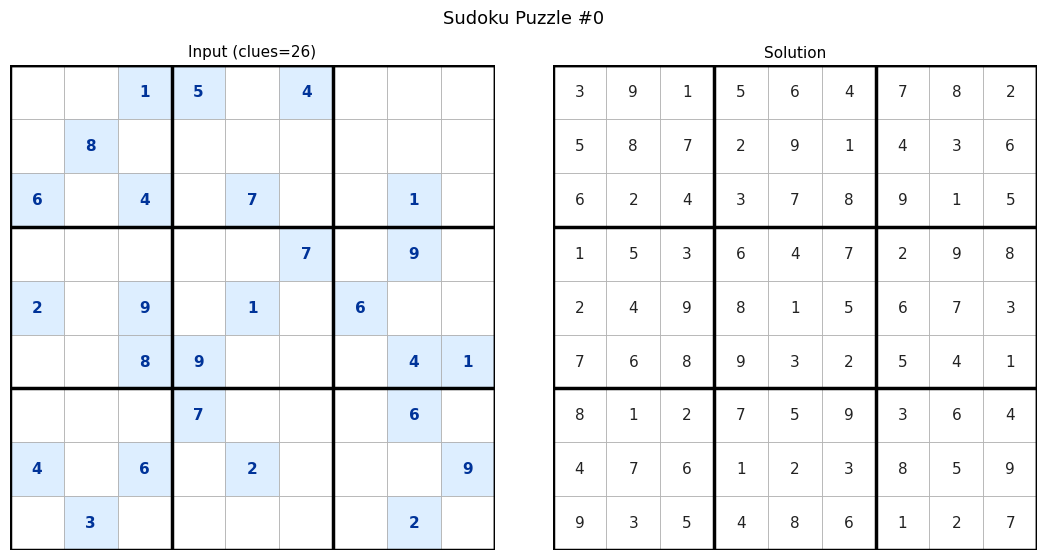

In [5]:
def decode_value(v):
    """Encoded value -> display string  (1=blank, 2-10=digits 1-9)"""
    if v == 1:
        return ''
    elif 2 <= v <= 10:
        return str(v - 1)
    return '?'

def draw_sudoku(ax, board_flat, title='', given_mask=None, highlight_errors=None):
    """Draw a 9x9 sudoku grid.
    board_flat      : (81,) encoded array
    given_mask      : (81,) bool, blue background for given (clue) cells
    highlight_errors: (81,) bool, red background for these cells
    """
    board = board_flat.reshape(9, 9)
    ax.set_xlim(0, 9)
    ax.set_ylim(0, 9)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title(title, fontsize=11, pad=6)

    for r in range(9):
        for c in range(9):
            idx = r * 9 + c
            val = board[r, c]
            x, y = c, 8 - r  # flip y-axis

            # Background color
            if highlight_errors is not None and highlight_errors[idx]:
                fc = '#FF9999'
            elif given_mask is not None and given_mask[idx]:
                fc = '#DDEEFF'
            else:
                fc = 'white'

            rect = patches.Rectangle((x, y), 1, 1, linewidth=0.5,
                                      edgecolor='#AAAAAA', facecolor=fc)
            ax.add_patch(rect)

            txt = decode_value(val)
            if txt:
                color = '#003399' if (given_mask is not None and given_mask[idx]) else '#222222'
                fontw = 'bold' if (given_mask is not None and given_mask[idx]) else 'normal'
                ax.text(x + 0.5, y + 0.5, txt, ha='center', va='center',
                        fontsize=11, color=color, fontweight=fontw)

    # 3x3 block borders (thick lines)
    for i in range(0, 10, 3):
        lw = 2.5 if i % 3 == 0 else 0.5
        ax.axhline(i, color='black', linewidth=lw)
        ax.axvline(i, color='black', linewidth=lw)
    ax.axhline(9, color='black', linewidth=2.5)
    ax.axvline(9, color='black', linewidth=2.5)


# Visualize group 0 (first original puzzle)
group_id = 0
start_ex = ds_train['group_indices'][group_id]
inp   = np.array(ds_train['inputs'][start_ex])   # original (aug_idx=0)
lbl   = np.array(ds_train['labels'][start_ex])
given = (inp != 1)  # given cells (not blank)

n_given = given.sum()
print(f'Puzzle #{group_id}: clues = {n_given}/81, blanks = {81 - n_given}')

fig, axes = plt.subplots(1, 2, figsize=(11, 5.5))
draw_sudoku(axes[0], inp, title=f'Input (clues={n_given})', given_mask=given)
draw_sudoku(axes[1], lbl, title='Solution')
plt.suptitle(f'Sudoku Puzzle #{group_id}', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 5. Clue Count Distribution

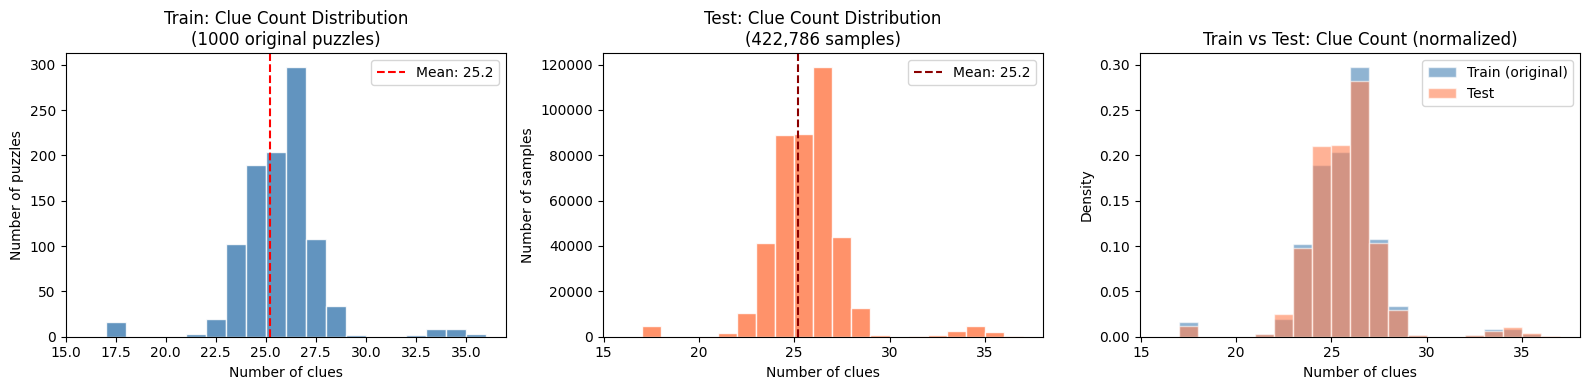

Train clues: min=17, max=35, mean=25.23, std=2.14
Test  clues: min=17, max=36, mean=25.21, std=2.10


In [6]:
# Count clues for each original puzzle (aug_idx=0 per group)
orig_indices = ds_train['group_indices'][:-1]           # first example of each group = original
orig_inputs  = np.array(ds_train['inputs'][orig_indices])  # (1000, 81)

clue_counts  = (orig_inputs != 1).sum(axis=1)   # number of given cells
blank_counts = 81 - clue_counts

# Test clue counts
test_inputs_arr  = np.array(ds_test['inputs'])
test_clue_counts = (test_inputs_arr != 1).sum(axis=1)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Train clue distribution
axes[0].hist(clue_counts, bins=range(clue_counts.min()-1, clue_counts.max()+2),
             color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title(f'Train: Clue Count Distribution\n({len(clue_counts)} original puzzles)')
axes[0].set_xlabel('Number of clues')
axes[0].set_ylabel('Number of puzzles')
axes[0].axvline(clue_counts.mean(), color='red', linestyle='--',
                label=f'Mean: {clue_counts.mean():.1f}')
axes[0].legend()

# Test clue distribution
axes[1].hist(test_clue_counts, bins=range(test_clue_counts.min()-1, test_clue_counts.max()+2),
             color='coral', edgecolor='white', alpha=0.85)
axes[1].set_title(f'Test: Clue Count Distribution\n({len(test_clue_counts):,} samples)')
axes[1].set_xlabel('Number of clues')
axes[1].set_ylabel('Number of samples')
axes[1].axvline(test_clue_counts.mean(), color='darkred', linestyle='--',
                label=f'Mean: {test_clue_counts.mean():.1f}')
axes[1].legend()

# Overlaid comparison
all_bins = range(
    min(clue_counts.min(), test_clue_counts.min()) - 1,
    max(clue_counts.max(), test_clue_counts.max()) + 2
)
axes[2].hist(clue_counts, bins=all_bins, alpha=0.6, color='steelblue',
             edgecolor='white', label='Train (original)', density=True)
axes[2].hist(test_clue_counts, bins=all_bins, alpha=0.6, color='coral',
             edgecolor='white', label='Test', density=True)
axes[2].set_title('Train vs Test: Clue Count (normalized)')
axes[2].set_xlabel('Number of clues')
axes[2].set_ylabel('Density')
axes[2].legend()

plt.tight_layout()
plt.show()

print(f'Train clues: min={clue_counts.min()}, max={clue_counts.max()}, '
      f'mean={clue_counts.mean():.2f}, std={clue_counts.std():.2f}')
print(f'Test  clues: min={test_clue_counts.min()}, max={test_clue_counts.max()}, '
      f'mean={test_clue_counts.mean():.2f}, std={test_clue_counts.std():.2f}')

## 6. Digit Distribution (Input vs Label)

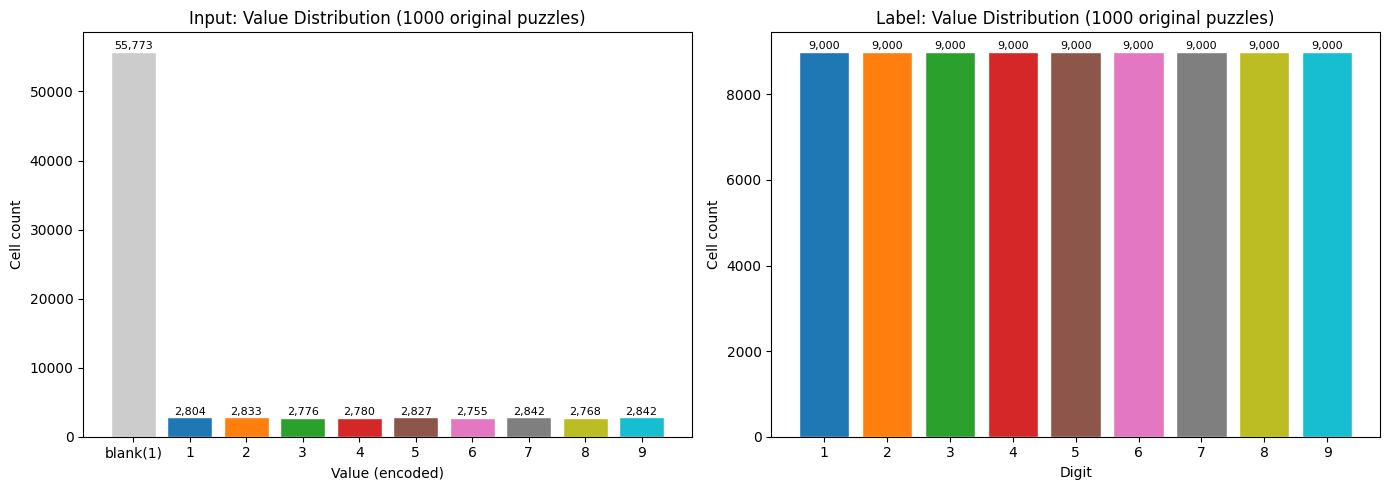

Label digit distribution (1-9): {np.int64(1): np.int64(9000), np.int64(2): np.int64(9000), np.int64(3): np.int64(9000), np.int64(4): np.int64(9000), np.int64(5): np.int64(9000), np.int64(6): np.int64(9000), np.int64(7): np.int64(9000), np.int64(8): np.int64(9000), np.int64(9): np.int64(9000)}
Expected count: 9000.0 per digit
Chi-squared statistic: 0.00  (df=8, vs uniform distribution)


In [7]:
# Use only 1000 original puzzles to keep computation light
sample_inp = orig_inputs                                          # (1000, 81)
sample_lbl = np.array(ds_train['labels'][orig_indices])          # (1000, 81)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Input value distribution (includes blank=1)
inp_vals, inp_counts = np.unique(sample_inp, return_counts=True)
inp_labels = ['blank(1)' if v == 1 else str(v - 1) for v in inp_vals]
colors_inp = ['#CCCCCC' if v == 1 else plt.cm.tab10((v-2)/8) for v in inp_vals]

bars = axes[0].bar(inp_labels, inp_counts, color=colors_inp, edgecolor='white')
axes[0].set_title('Input: Value Distribution (1000 original puzzles)')
axes[0].set_xlabel('Value (encoded)')
axes[0].set_ylabel('Cell count')
for bar, cnt in zip(bars, inp_counts):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{cnt:,}', ha='center', va='bottom', fontsize=8)

# Label value distribution (no blanks)
lbl_vals, lbl_counts = np.unique(sample_lbl, return_counts=True)
lbl_xlabels = [str(v - 1) for v in lbl_vals]
colors_lbl  = [plt.cm.tab10((v-2)/8) for v in lbl_vals]

bars2 = axes[1].bar(lbl_xlabels, lbl_counts, color=colors_lbl, edgecolor='white')
axes[1].set_title('Label: Value Distribution (1000 original puzzles)')
axes[1].set_xlabel('Digit')
axes[1].set_ylabel('Cell count')
for bar, cnt in zip(bars2, lbl_counts):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                 f'{cnt:,}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

# Chi-squared test for uniform distribution
digit_counts = lbl_counts
expected = digit_counts.sum() / 9
chi2 = ((digit_counts - expected)**2 / expected).sum()
print(f'Label digit distribution (1-9): {dict(zip([v-1 for v in lbl_vals], lbl_counts))}')
print(f'Expected count: {expected:.1f} per digit')
print(f'Chi-squared statistic: {chi2:.2f}  (df=8, vs uniform distribution)')

## 7. Spatial Distribution of Blank Cells (Heatmap)

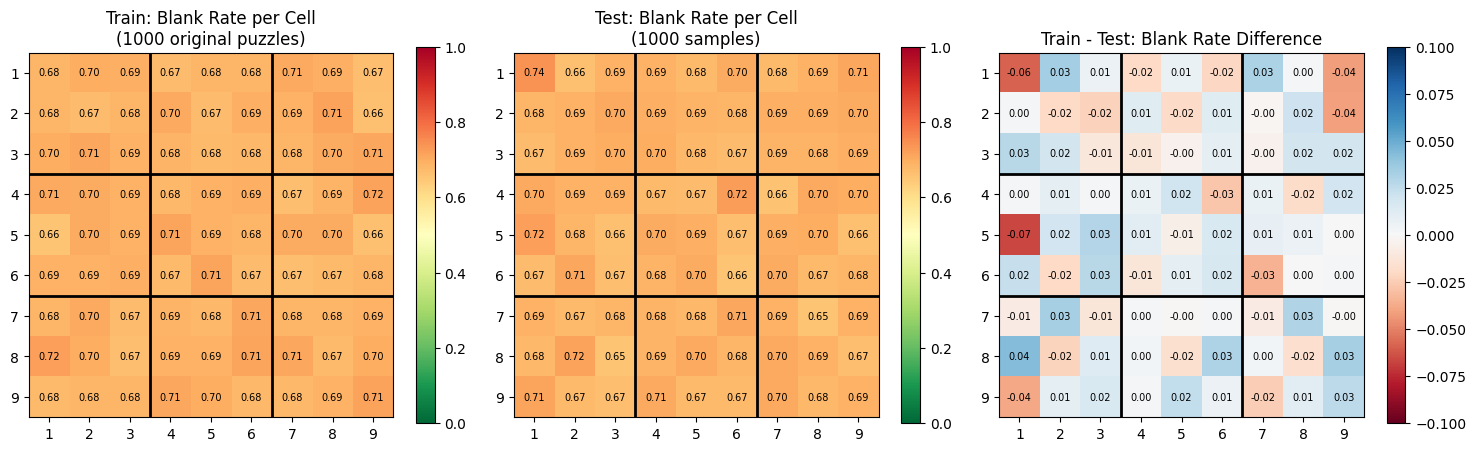

Train: overall blank rate = 0.689
Test : overall blank rate = 0.687


In [8]:
# Blank probability heatmap per cell position
blank_map_train = (sample_inp == 1).reshape(len(sample_inp), 9, 9).mean(axis=0)  # (9,9)

test_orig_inp  = np.array(ds_test['inputs'][:1000])  # 1000 samples from test
blank_map_test = (test_orig_inp == 1).reshape(len(test_orig_inp), 9, 9).mean(axis=0)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

def draw_heatmap(ax, heatmap, title, vmin=0, vmax=1):
    im = ax.imshow(heatmap, cmap='RdYlGn_r', vmin=vmin, vmax=vmax)
    ax.set_title(title)
    ax.set_xticks(range(9))
    ax.set_yticks(range(9))
    ax.set_xticklabels([str(i+1) for i in range(9)])
    ax.set_yticklabels([str(i+1) for i in range(9)])
    # 3x3 block borders
    for i in [2.5, 5.5]:
        ax.axhline(i, color='black', linewidth=2)
        ax.axvline(i, color='black', linewidth=2)
    for r in range(9):
        for c in range(9):
            ax.text(c, r, f'{heatmap[r,c]:.2f}', ha='center', va='center',
                    fontsize=7, color='black')
    plt.colorbar(im, ax=ax, shrink=0.8)

draw_heatmap(axes[0], blank_map_train, 'Train: Blank Rate per Cell\n(1000 original puzzles)')
draw_heatmap(axes[1], blank_map_test,  'Test: Blank Rate per Cell\n(1000 samples)')
draw_heatmap(axes[2], blank_map_train - blank_map_test,
             'Train - Test: Blank Rate Difference', vmin=-0.1, vmax=0.1)
axes[2].images[0].set_cmap('RdBu')

plt.tight_layout()
plt.show()

print(f'Train: overall blank rate = {blank_map_train.mean():.3f}')
print(f'Test : overall blank rate = {blank_map_test.mean():.3f}')

## 8. Augmentation Visualization

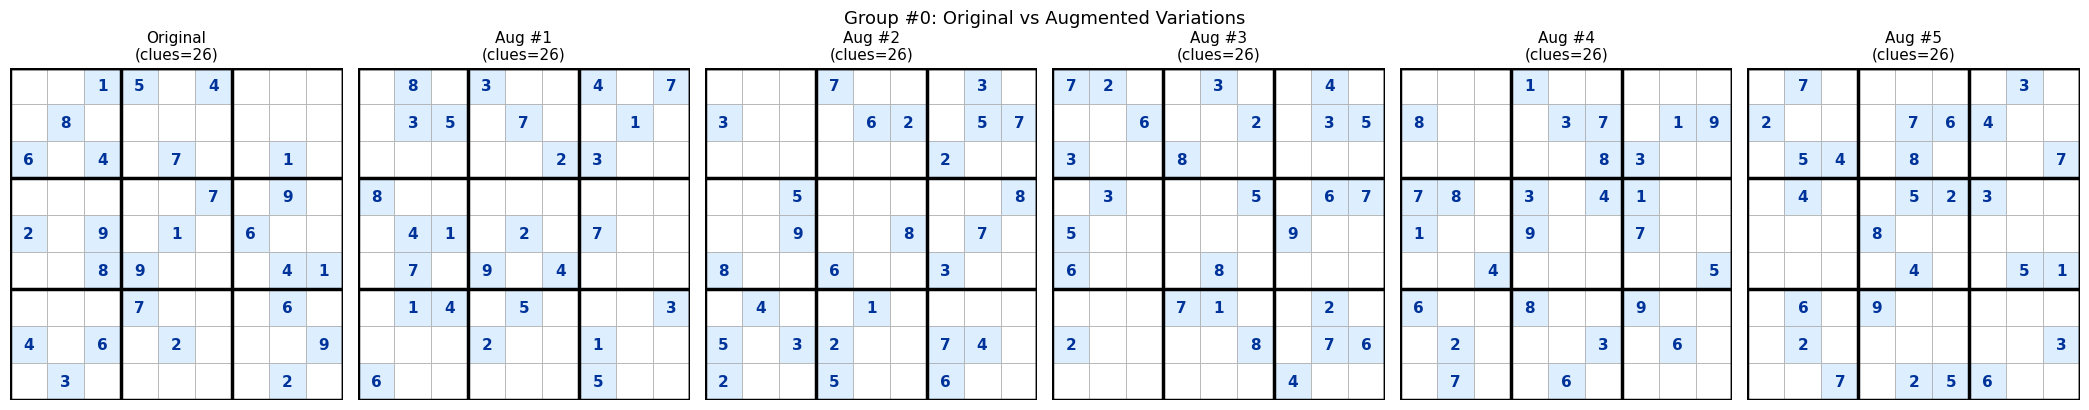

Group #0 clue counts across first 50 variations: [26] (all identical: True)


In [9]:
# Show different variations of the same original puzzle side by side
group_id  = 0
g_start   = int(ds_train['group_indices'][group_id])
g_end     = int(ds_train['group_indices'][group_id + 1])
n_show_aug = 6  # number of variations to display

indices_to_show = [g_start] + list(range(g_start + 1, g_start + n_show_aug))

fig, axes = plt.subplots(1, n_show_aug, figsize=(3.5 * n_show_aug, 4))
for i, idx in enumerate(indices_to_show):
    inp_i   = np.array(ds_train['inputs'][idx])
    given_i = (inp_i != 1)
    label   = 'Original' if i == 0 else f'Aug #{i}'
    n_clues = given_i.sum()
    draw_sudoku(axes[i], inp_i,
                title=f'{label}\n(clues={n_clues})',
                given_mask=given_i)

plt.suptitle(f'Group #{group_id}: Original vs Augmented Variations', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Confirm clue count is unchanged by augmentation
group_inps  = np.array(ds_train['inputs'][g_start:g_start+50])
group_clues = (group_inps != 1).sum(axis=1)
print(f'Group #{group_id} clue counts across first 50 variations: '
      f'{np.unique(group_clues)} (all identical: {len(np.unique(group_clues)) == 1})')

## 9. Digit Distribution by Row / Column / Block (Constraint Verification)

Solution validity check (first 100): 100/100 valid


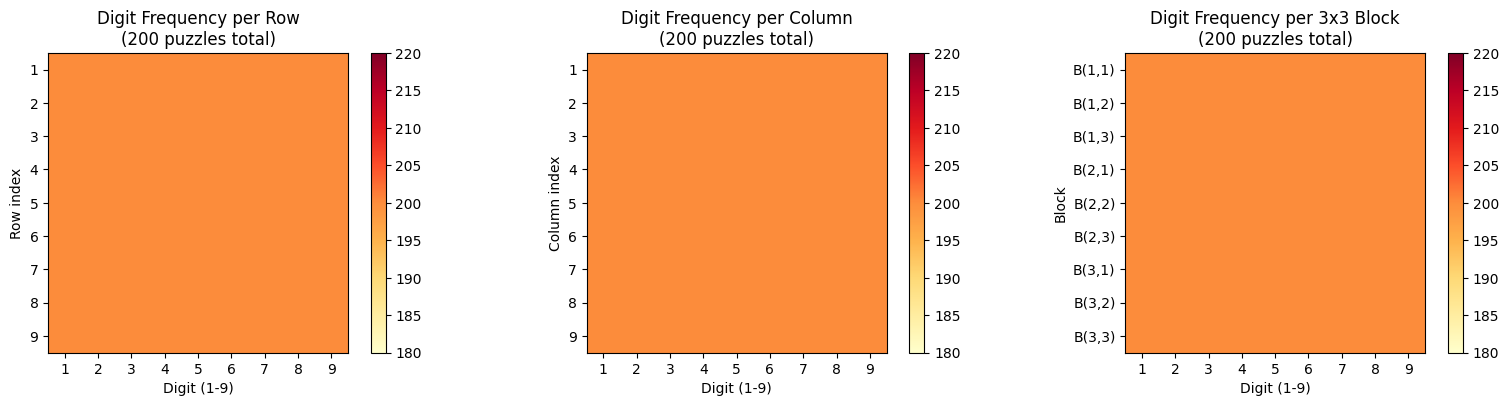

In [10]:
def check_sudoku_validity(label_flat):
    """Verify sudoku constraints (each row/col/3x3 block contains 1-9 exactly once)"""
    board    = (label_flat - 1).reshape(9, 9)  # convert back to 1-9
    expected = set(range(1, 10))
    valid    = True
    for r in range(9):
        if set(board[r]) != expected:
            valid = False; break
    for c in range(9):
        if set(board[:, c]) != expected:
            valid = False; break
    for br in range(3):
        for bc in range(3):
            block = board[br*3:(br+1)*3, bc*3:(bc+1)*3]
            if set(block.flatten()) != expected:
                valid = False; break
    return valid

# Verify first 100 solutions
n_check = 100
valid_count = sum(
    check_sudoku_validity(np.array(ds_train['labels'][i]))
    for i in range(n_check)
)
print(f'Solution validity check (first {n_check}): {valid_count}/{n_check} valid')

# Digit frequency per row / column / 3x3 block
sample_lbls = np.array(ds_train['labels'][orig_indices[:200]]) - 1  # (200,81), values 1-9
sample_lbls = sample_lbls.reshape(200, 9, 9)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Per-row digit frequency
row_digit_counts = np.zeros((9, 9))  # row x digit
for d in range(1, 10):
    row_digit_counts[:, d-1] = (sample_lbls == d).sum(axis=(0, 2))
im0 = axes[0].imshow(row_digit_counts, cmap='YlOrRd')
axes[0].set_title('Digit Frequency per Row\n(200 puzzles total)')
axes[0].set_xlabel('Digit (1-9)')
axes[0].set_ylabel('Row index')
axes[0].set_xticks(range(9)); axes[0].set_xticklabels(range(1, 10))
axes[0].set_yticks(range(9)); axes[0].set_yticklabels(range(1, 10))
plt.colorbar(im0, ax=axes[0])

# Per-column digit frequency
col_digit_counts = np.zeros((9, 9))  # col x digit
for d in range(1, 10):
    col_digit_counts[:, d-1] = (sample_lbls == d).sum(axis=(0, 1))
im1 = axes[1].imshow(col_digit_counts, cmap='YlOrRd')
axes[1].set_title('Digit Frequency per Column\n(200 puzzles total)')
axes[1].set_xlabel('Digit (1-9)')
axes[1].set_ylabel('Column index')
axes[1].set_xticks(range(9)); axes[1].set_xticklabels(range(1, 10))
axes[1].set_yticks(range(9)); axes[1].set_yticklabels(range(1, 10))
plt.colorbar(im1, ax=axes[1])

# Per-block digit frequency
block_counts = np.zeros((9, 9))  # block_id x digit
for bid, (br, bc) in enumerate([(r, c) for r in range(3) for c in range(3)]):
    block = sample_lbls[:, br*3:(br+1)*3, bc*3:(bc+1)*3].reshape(200, -1)
    for d in range(1, 10):
        block_counts[bid, d-1] = (block == d).sum()
block_labels = [f'B({r+1},{c+1})' for r in range(3) for c in range(3)]
im2 = axes[2].imshow(block_counts, cmap='YlOrRd')
axes[2].set_title('Digit Frequency per 3x3 Block\n(200 puzzles total)')
axes[2].set_xlabel('Digit (1-9)')
axes[2].set_ylabel('Block')
axes[2].set_xticks(range(9)); axes[2].set_xticklabels(range(1, 10))
axes[2].set_yticks(range(9)); axes[2].set_yticklabels(block_labels)
plt.colorbar(im2, ax=axes[2])

plt.tight_layout()
plt.show()

## 10. Puzzle Gallery

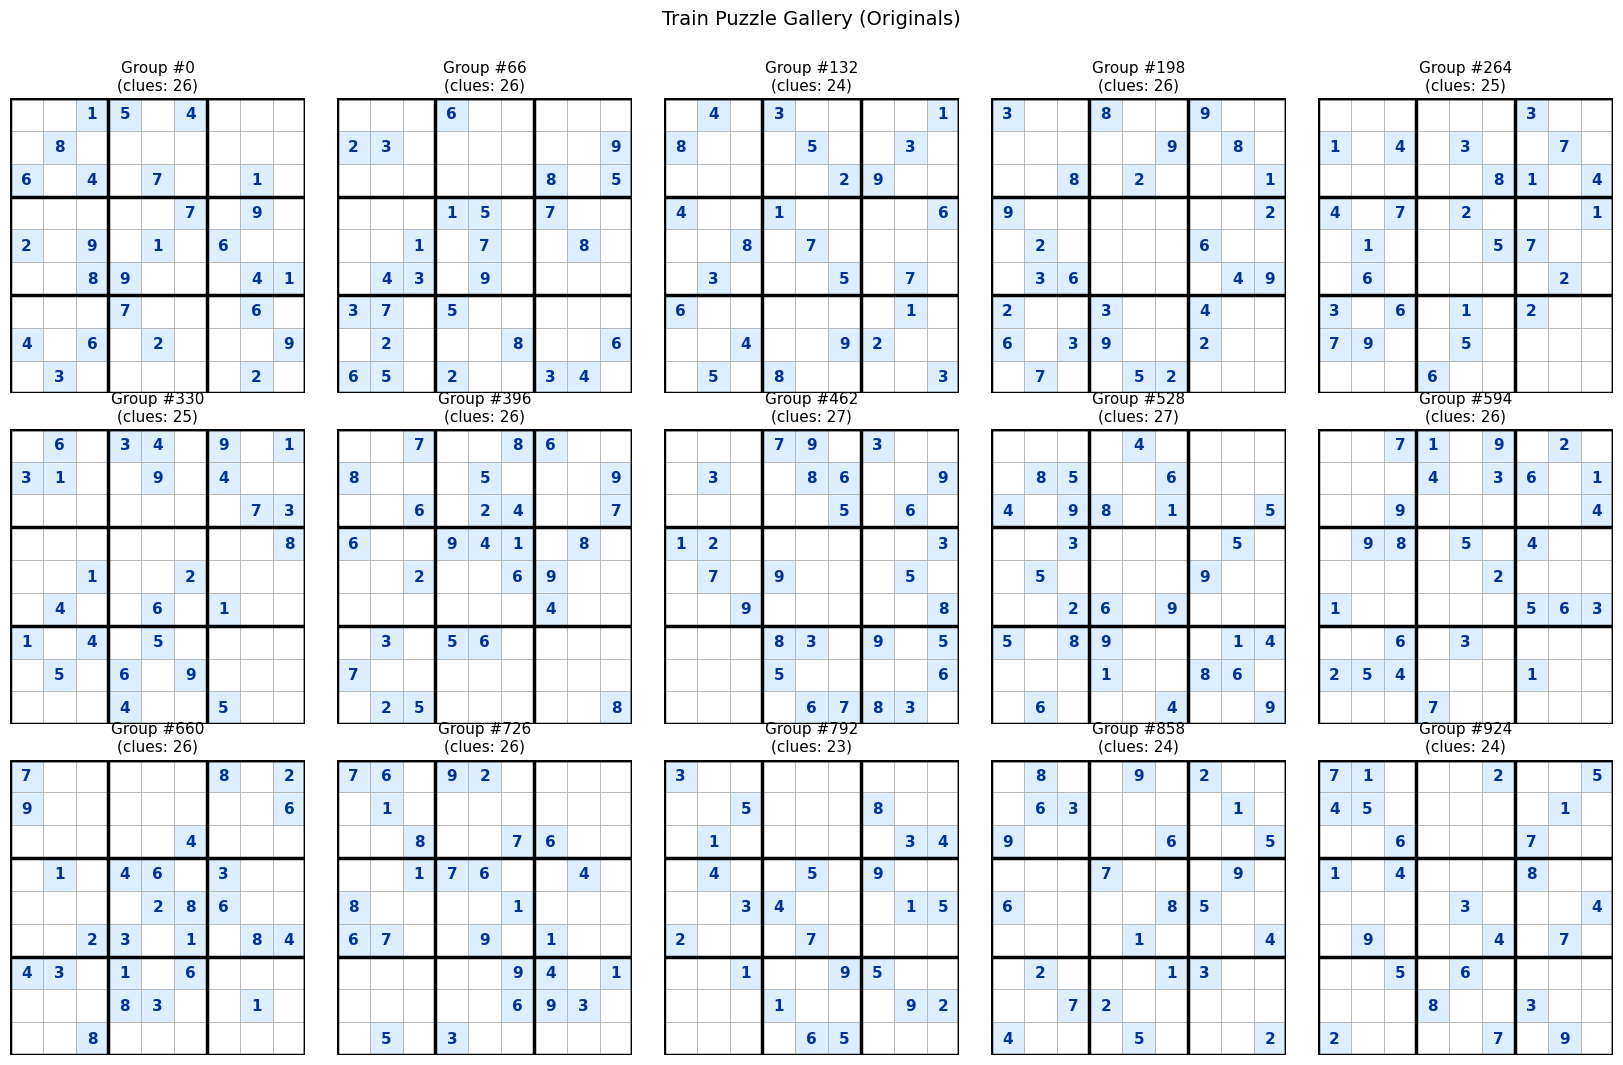

In [11]:
n_rows, n_cols = 3, 5
n_puzzles = n_rows * n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(3.3 * n_cols, 3.5 * n_rows))

# Evenly spaced selection for diversity
group_step = max(1, train_meta.total_groups // n_puzzles)
group_ids  = [i * group_step for i in range(n_puzzles)]

for ax, gid in zip(axes.flatten(), group_ids):
    idx     = int(ds_train['group_indices'][gid])
    inp_i   = np.array(ds_train['inputs'][idx])
    given_i = (inp_i != 1)
    n_clue  = given_i.sum()
    draw_sudoku(ax, inp_i, title=f'Group #{gid}\n(clues: {n_clue})', given_mask=given_i)

plt.suptitle('Train Puzzle Gallery (Originals)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 11. Input vs Solution Diff (Cells to Predict)

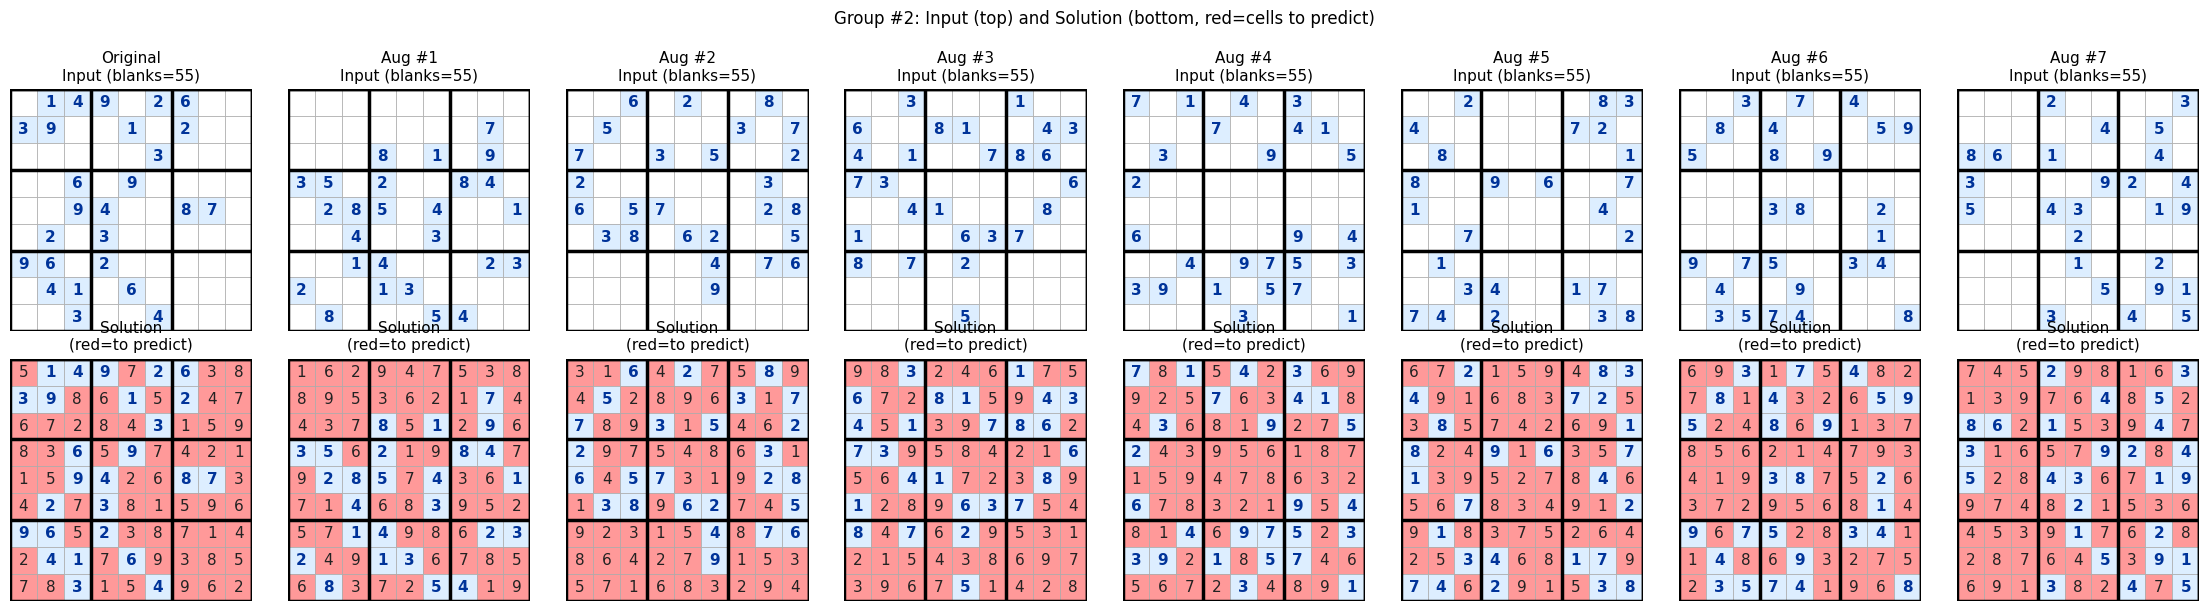

In [12]:
# Show which cells need to be predicted (blank in input)
# and whether blank positions change across augmentations
group_id   = 2
g_start    = int(ds_train['group_indices'][group_id])
g_end      = int(ds_train['group_indices'][group_id + 1])
n_aug_show = min(8, g_end - g_start)

fig, axes = plt.subplots(2, n_aug_show, figsize=(2.8 * n_aug_show, 6))

for i in range(n_aug_show):
    idx     = g_start + i
    inp_i   = np.array(ds_train['inputs'][idx])
    lbl_i   = np.array(ds_train['labels'][idx])
    given_i = (inp_i != 1)
    blank_i = ~given_i

    label_str = 'Original' if i == 0 else f'Aug #{i}'
    draw_sudoku(axes[0, i], inp_i,
                title=f'{label_str}\nInput (blanks={blank_i.sum()})',
                given_mask=given_i)
    # Highlight cells that need to be predicted (were blank in input)
    draw_sudoku(axes[1, i], lbl_i,
                title='Solution\n(red=to predict)',
                given_mask=given_i,
                highlight_errors=blank_i)

plt.suptitle(f'Group #{group_id}: Input (top) and Solution (bottom, red=cells to predict)',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

## 12. Overall Statistics Summary

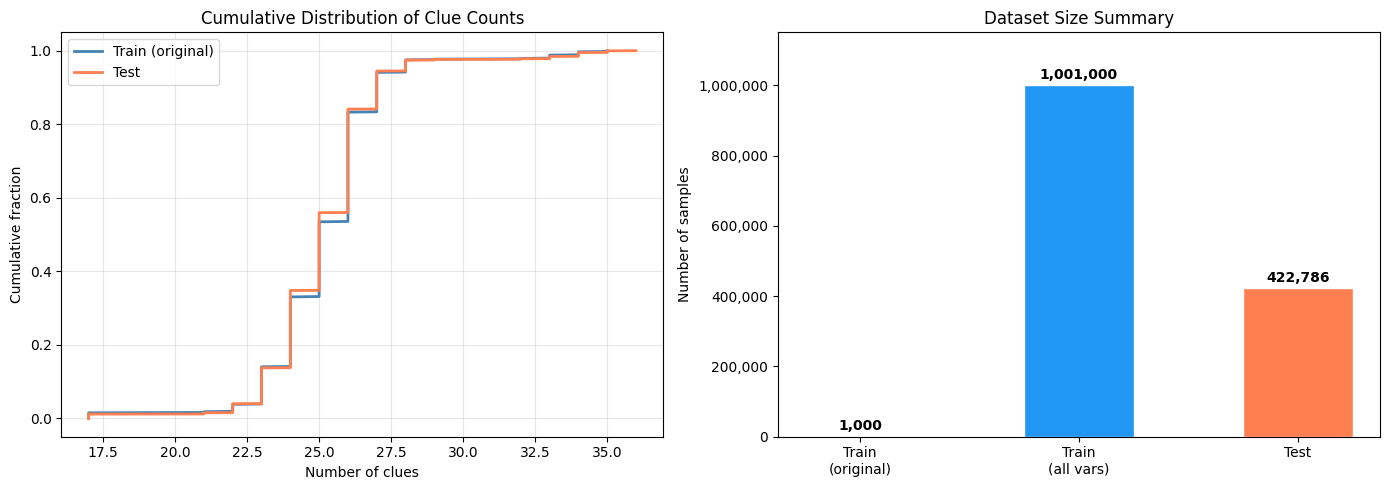


=== Dataset Statistics Summary ===
Train: 1,000 groups x 1001 variations = 1,001,000 samples
Test : 422,786 samples
Seq length : 81 (9x9)
Vocab size : 11 (PAD=0, blank=1, digits 1-9 -> 2-10)
Train clues: 17-35 (mean 25.2)
Test  clues: 17-36 (mean 25.2)


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Cumulative distribution of clue counts
sorted_clues = np.sort(clue_counts)
axes[0].plot(sorted_clues, np.linspace(0, 1, len(sorted_clues)),
             color='steelblue', linewidth=2, label='Train (original)')
sorted_test = np.sort(test_clue_counts)
axes[0].plot(sorted_test, np.linspace(0, 1, len(sorted_test)),
             color='coral', linewidth=2, label='Test')
axes[0].set_xlabel('Number of clues')
axes[0].set_ylabel('Cumulative fraction')
axes[0].set_title('Cumulative Distribution of Clue Counts')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Sample count summary bar chart
categories     = ['Train\n(original)', 'Train\n(all vars)', 'Test']
counts_summary = [train_meta.total_groups, n_train_examples, n_test_examples]
colors_summary = ['steelblue', '#2196F3', 'coral']
bars = axes[1].bar(categories, counts_summary, color=colors_summary, edgecolor='white', width=0.5)
axes[1].set_title('Dataset Size Summary')
axes[1].set_ylabel('Number of samples')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
for bar, cnt in zip(bars, counts_summary):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + max(counts_summary) * 0.01,
                 f'{cnt:,}', ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[1].set_ylim(0, max(counts_summary) * 1.15)

plt.tight_layout()
plt.show()

print('\n=== Dataset Statistics Summary ===')
print(f'Train: {train_meta.total_groups:,} groups x {aug_per_puzzle+1} variations = {n_train_examples:,} samples')
print(f'Test : {n_test_examples:,} samples')
print(f'Seq length : {train_meta.seq_len} (9x9)')
print(f'Vocab size : {train_meta.vocab_size} (PAD=0, blank=1, digits 1-9 -> 2-10)')
print(f'Train clues: {clue_counts.min()}-{clue_counts.max()} (mean {clue_counts.mean():.1f})')
print(f'Test  clues: {test_clue_counts.min()}-{test_clue_counts.max()} (mean {test_clue_counts.mean():.1f})')